In [15]:
import numpy as np
import pandas as pd

train = pd.read_csv("input/titanic/train.csv")
test = pd.read_csv("input/titanic/test.csv")

print(f"訓練データの形状: {train.shape}")
print(train.head())

訓練データの形状: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500

In [20]:
# 今回は簡単のため、数値データのみを使い、欠損値は中央値で埋めます
# まず Name から敬称を抜き出して、タイトル特徴量として追加します

title_mapping = {
    "Mr": 0,
    "Miss": 1,
    "Mrs": 2,
    "Master": 3,
    "Rare": 4,
}

for df in [train, test]:
    df["Title"] = df["Name"].str.extract(r",\s*([A-Za-z]+)\.", expand=False)
    df["Title"] = (
        df["Title"]
        .replace({
            "Mr": "Mr",
            "Miss": "Miss",
            "Mrs": "Mrs",
            "Master": "Master",
            "Dr": "Rare",
            "Rev": "Rare",
            "Col": "Rare",
            "Major": "Rare",
            "Mlle": "Miss",
            "Ms": "Miss",
            "Mme": "Mrs",
            "Countess": "Rare",
            "Lady": "Rare",
            "Jonkheer": "Rare",
            "Don": "Rare",
            "Sir": "Rare",
            "Capt": "Rare",
            "Dona": "Rare",
        })
        .fillna("Rare")
        .map(title_mapping)
    )

features = ["Pclass", "Age", "SibSp", "Parch", "Fare", "Title"]

# 欠損値（NaN）の補正
train["Age"] = train["Age"].fillna(train["Age"].median())
test["Age"] = test["Age"].fillna(test["Age"].median())
test["Fare"] = test["Fare"].fillna(test["Fare"].median())

X_train = train[features]
y_train = train["Survived"]
X_test = test[features]


In [21]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# 簡易的なバリデーションデータの分割
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# モデルの定義と学習
model = lgb.LGBMClassifier(random_state=42, verbose=-1)
model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])

# テストデータに対する予測
preds = model.predict(X_test)


In [22]:
import os

# 出力用フォルダを作成
os.makedirs("output", exist_ok=True)

# 提出形式に整形
submission = pd.DataFrame({"PassengerId": test["PassengerId"], "Survived": preds})

# 保存
submission.to_csv("output/submission.csv", index=False)
print("提出用ファイルの作成が完了しました！")


提出用ファイルの作成が完了しました！


=== 欠損値の確認 ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Title            0
dtype: int64

=== 性別・階級・乗船港・タイトルごとの生存率 ===

[Pclass]
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

[Sex]
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

[Embarked]
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

[Title]
Title
2    0.793651
1    0.702703
3    0.575000
4    0.347826
0    0.156673
Name: Survived, dtype: float64

=== 年齢の分布（生存有無別）===

=== 料金の分布（生存有無別）===


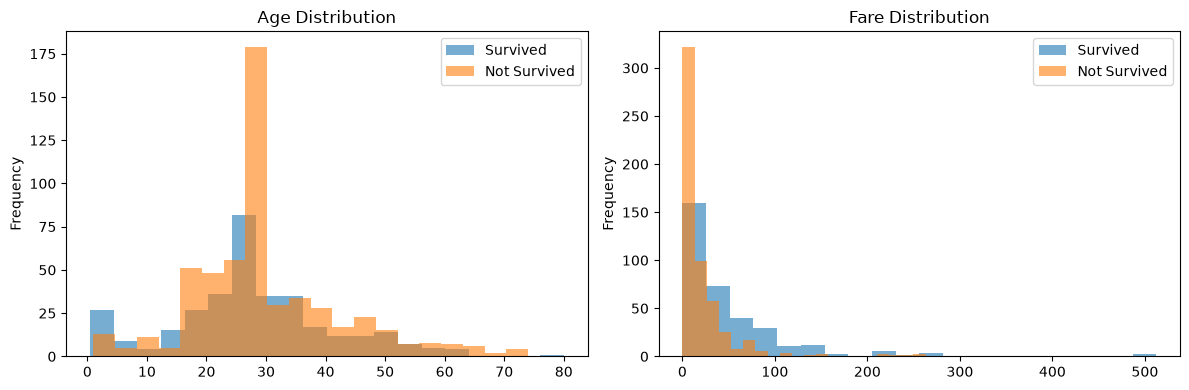

In [24]:
# EDA: まずデータの特徴と生存との関係を確認します
import matplotlib.pyplot as plt

print("=== 欠損値の確認 ===")
print(train.isnull().sum())

print("\n=== 性別・階級・乗船港・タイトルごとの生存率 ===")
for col in ["Pclass", "Sex", "Embarked", "Title"]:
    if col in train.columns:
        summary = train.groupby(col)["Survived"].mean().sort_values(ascending=False)
        print(f"\n[{col}]")
        print(summary)

print("\n=== 年齢の分布（生存有無別）===")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train[train["Survived"] == 1]["Age"].dropna().plot.hist(ax=axes[0], bins=20, alpha=0.6, label="Survived")
train[train["Survived"] == 0]["Age"].dropna().plot.hist(ax=axes[0], bins=20, alpha=0.6, label="Not Survived")
axes[0].set_title("Age Distribution")
axes[0].legend()

print("\n=== 料金の分布（生存有無別）===")
train[train["Survived"] == 1]["Fare"].dropna().plot.hist(ax=axes[1], bins=20, alpha=0.6, label="Survived")
train[train["Survived"] == 0]["Fare"].dropna().plot.hist(ax=axes[1], bins=20, alpha=0.6, label="Not Survived")
axes[1].set_title("Fare Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()
